# <img style="float: left; padding-right: 20px; width: 200px" src="https://raw.githubusercontent.com/raxlab/imt2200-data/main/media/logo.jpg">  IMT 2200 - Introducción a Ciencia de Datos
**Pontificia Universidad Católica de Chile**<br>
**Instituto de Ingeniería Matemática y Computacional**<br>
**Semestre 2025-S2**<br>
**Profesor:** Rodrigo A. Carrasco <br>
**Alumno: Israel Pino Saavedra**

---
# <h1><center>Tarea 03: Exploración de datos </center></h1>

**Fecha de Entrega:** 28 de octubre de 2025, a las 23:59.

**Fecha de publicación**: 14 de octubre de 2025.

**Formato de entrega:** Notebook ejecutado y comentado (`.ipynb`) en el módulo de Tarea 03 habilitado en Canvas.

---

# <h1><center>Respuesta 2.1 </center></h1>


Investigue sobre este índice y responda de manera concisa: 
* ¿En qué consiste el IVM? ¿Qué rango de valores toma y qué significan? 
* ¿Cómo se obtiene el IVM de un establecimiento educacional?

**Respuesta**:  EL IVM es una medida generada a partir de la correlación de variables que representan las dimensiones o factores más relevantes de un concepto de vulnerabilidad no observable, según la trayectoria escolar del estudiante. El IVM fue desarrollado entre los años 2015 y 2016 mediante un convenio entre JUNAEB y Pontificia Universidad Católica de Chile.  Los rangos de valores van de 0 a 100 , donde 100 expresa la mayor vulnerabilidad posible, se puede expresar en categorias bajo, medio, alto y muy alto.

Se obtiene anualmente mediante una Encuesta de vulnerabilidad aplicado a todos los hogares de estudiantes que cursan prekínder, kínder, 1° básico, 5° básico y I° Medio en establecimientos que reciben subvención del Estado de Chile. Además, se obtiene información del Registro de Padres, Madres y Embarazadas y del Mapa Nutricional

Por otra parte, se consideran otros registros administrativos y estadísticas públicas que posee el Estado, provenientes de las siguientes instituciones:
Ministerio de Educación (MINEDUC)
Ministerio de Desarrollo Social (MDS)
Servicio de Registro Civil e Identificación (SRCeI)
Fondo Nacional de Salud (FONASA)
Servicio Nacional de Menores (SENAME)
Sistema Nacional de Información Municipal (SINIM)
Instituto Nacional de Estadísticas (INE)


---

# <h1><center>Respuesta 3.1 Datos de establecimientos (0.5 puntos) </center></h1>

Cargue los datos de los establecimientos en cuatro DataFrames distintos.


In [15]:
import matplotlib.pyplot as plt

In [16]:
# @title Respuesta 3.1

import pandas as pd


nombre_archivo = "data/IVM_Establecimientos_2025-2.xlsx"

dfP= pd.read_excel(
    nombre_archivo,
    sheet_name="Parvularia")

In [17]:
#Verifico que corresponda el data frame con la visualización del archivo Excel
nombre_imagen= "Revision_tabla.png"

from IPython.display import Image, display
display(Image(filename=nombre_imagen))

# Visualizo si hay correspondencia
dfP.head()

FileNotFoundError: [Errno 2] No such file or directory: 'Revision_tabla.png'

In [ ]:
nombre_imagen2="Total filas data original.png"
from IPython.display import Image, display
display(Image(filename=nombre_imagen2))

# Visualizo si hay correspondencia
dfP.info()

In [ ]:
#Procedo a hacer lo mismo con cada pestaña de excel o nivel

nombre_archivo = "data/IVM_Establecimientos_2025-2.xlsx"

df1 = pd.read_excel(
    nombre_archivo,
    sheet_name="1º Ciclo Básico")

df2 = pd.read_excel(
    nombre_archivo,
    sheet_name="2º Ciclo Básico")

dfM = pd.read_excel(
    nombre_archivo,
    sheet_name="Media")


**Proceso de limpieza (manejo de valores nulos, duplicados, inválidos, transformación de tipos de datos, etc)** 

In [ ]:
#Reviso los nulos del primer nivel
dfP.isnull().sum()

In [ ]:
#los nulos de las demas
df1.isnull().sum()

In [ ]:
df2.isnull().sum()

In [ ]:
dfM.isnull().sum()

In [ ]:
#Conclusion: no hay valores nulos

Verifico valores duplicados

In [ ]:
dfP.duplicated().sum()


In [ ]:
df1.duplicated().sum()

In [ ]:
df2.duplicated().sum()


In [ ]:
dfM.duplicated().sum()

In [ ]:
#Conclusion: no hay valores duplicados

**Verifico valores inválidos**

In [ ]:
df1.info()

In [ ]:
df1.sample(15)

In [ ]:
#Busco valores extraños en una columna
#asi encuentro los datos unicos de cada columna
dfP['DS_RURALIDAD'].unique()


In [ ]:
dfP.columns

In [ ]:
lista_columnas= ['ID_RBD', 'DV_RBD', 'DS_NOM_ESTABLE', 'DS_TIPO_DEPENDENCIA',
       'DS_RURALIDAD', 'ID_REGION_ESTABLE', 'ID_PROVINCIA_ESTABLE',
       'ID_COMUNA_ESTABLE', 'DS_COMUNA_ESTABLE', 'N EVALUADO',
       'IVM Establecimiento', 'IVM Bajo', 'IVM Medio', 'IVM Alto',
       'IVM Muy Alto', 'IVM Salud', 'IVM CSE Familiar',
       'IVM Estimulación y Apoyo', 'IVM Familia', 'IVM CSE Comunal',
       'IVM Derechos']

for columna in lista_columnas:
    print(f"Valores únicos en la columna {columna}:")
    print(dfP[columna].unique())
    print("\n")

#Si observamos el output no truncado, obtenemos todos los datos no repetidos por columna o datos únicos

Valores únicos en la columna ID_RBD:
[    2     8     9 ... 42153 42170 42243]


Valores únicos en la columna DV_RBD:
[7 6 4 8 2 0 5 3 1 9]


Valores únicos en la columna DS_NOM_ESTABLE:
['PARVULARIO LAS ESPIGUITAS' 'COLEGIO INTEGRADO EDUARDO FREI MONTALVA'
 'ESCUELA REPUBLICA DE ISRAEL' ... 'ESCUELA ESPECIAL DE LENGUAJE IERUBA'
 'ESCUELA ESPECIAL DE LENGUAJE QISPI KAY'
 'ESCUELA ESPECIAL DE LENGUAJE PLAYGARDEN']


Valores únicos en la columna DS_TIPO_DEPENDENCIA:
['Servicio Local de Educación(SLE)' 'Particular Subvencionado'
 'Municipal DAEM' 'Corporación Municipal']


Valores únicos en la columna DS_RURALIDAD:
['Urbano' 'Rural']


Valores únicos en la columna ID_REGION_ESTABLE:
[15  1  2  3  4  5  6  7 16  8  9 14 10 11 12 13]


Valores únicos en la columna ID_PROVINCIA_ESTABLE:
[151 152  11  14  23  22  21  32  31  33  41  43  42  54  53  57  55  58
  51  56  61  63  62  73  71  74  72 161 163 162  83  81  82  92  91 141
 142 103 101 102 104 111 112 114 113 124 121 123 122 131 135 1

In [ ]:
"""Podemos ver que por ejemplo , los valores de la columna "ID_REGION_ESTABLE" es razonable, son las 16 regiones

Valores únicos en la columna "ID_REGION_ESTABLE":
[15  1  2  3  4  5  6  7 16  8  9 14 10 11 12 13]"""

In [ ]:
#Ahora lo hago con cada DF
lista_columnas_df1=df1.columns
for columna in lista_columnas_df1:
    print(f"Valores únicos en la columna {columna}:")
    print(df1[columna].unique())
    print("\n")

In [ ]:
#Ahora lo hago con DF2
lista_columnas_df2=df2.columns
for columna in lista_columnas_df2:
    print(f"Valores únicos en la columna {columna}:")
    print(df2[columna].unique())
    print("\n")

In [ ]:
#por ultimo con dfM 
lista_columnas_dfM=dfM.columns
for columna in lista_columnas_dfM:
    print(f"Valores únicos en la columna {columna}:")
    print(dfM[columna].unique())
    print("\n")

**Para explorar mejor la tabla y verificar si los tipos de datos están bien, vemos cuantos datos distintos tiene cada columna  y buscamos candidatos para category**

In [ ]:
"""datafram sobre el que trabajamos:""" 
"""trabajamos sobre el dfP""" 
dfn= dfP

"""creamos un df del numero de valores unicos de cada columna""" 
lista_columnas_dfn= dfn.columns
dicc_acumulado=[]
for columna in lista_columnas_dfn: 
    dict_nunique_dfn={ 
        "Columna" : columna,
        "Número de valores únicos" : dfn[columna].nunique()}
    dicc_acumulado.append(dict_nunique_dfn) 

df_nunique_dfn=pd.DataFrame(dicc_acumulado)
df_nunique_dfn.head(len(df_nunique_dfn))

In [ ]:
"""trabajamos sobre df1""" 
dfn= df1

"""creamos un df del numero de valores unicos de cada columna""" 
lista_columnas_dfn= dfn.columns
dicc_acumulado=[]
for columna in lista_columnas_dfn: 
    dict_nunique_dfn={ 
        "Columna" : columna,
        "Número de valores únicos" : dfn[columna].nunique()}
    dicc_acumulado.append(dict_nunique_dfn) 

df_nunique_dfn=pd.DataFrame(dicc_acumulado)
df_nunique_dfn.head(len(df_nunique_dfn))

In [ ]:
"""trabajamos sobre df2""" 
dfn= df2

"""creamos un df del numero de valores unicos de cada columna""" 
lista_columnas_dfn= dfn.columns
dicc_acumulado=[]
for columna in lista_columnas_dfn: 
    dict_nunique_dfn={ 
        "Columna" : columna,
        "Número de valores únicos" : dfn[columna].nunique()}
    dicc_acumulado.append(dict_nunique_dfn) 

df_nunique_dfn=pd.DataFrame(dicc_acumulado)
df_nunique_dfn.head(len(df_nunique_dfn))

In [ ]:
"""trabajamos sobre dfM""" 
dfn= dfM

"""creamos un df del numero de valores unicos de cada columna""" 
lista_columnas_dfn= dfn.columns
dicc_acumulado=[]
for columna in lista_columnas_dfn: 
    dict_nunique_dfn={ 
        "Columna" : columna,
        "Número de valores únicos" : dfn[columna].nunique()}
    dicc_acumulado.append(dict_nunique_dfn) 

df_nunique_dfn=pd.DataFrame(dicc_acumulado)
df_nunique_dfn.head(len(df_nunique_dfn))

In [ ]:
#Conclusión: No se observan valores extraños en ninguna columna de los dataframes

**Transformación de datos a category**

In [ ]:
dfP.head(2)

In [ ]:
"""info de dfP""" 
dfP.info()

In [ ]:
"""datafram sobre el que trabajamos:""" 
"""trabajamos sobre el dfP""" 
dfn= dfP

"""Convertimos las columnas categóricas a tipo 'category'"""
lista_columnas=[
    "DV_RBD",
    "DS_TIPO_DEPENDENCIA",
    "DS_RURALIDAD",
    "ID_REGION_ESTABLE",
    "ID_PROVINCIA_ESTABLE",
    "ID_COMUNA_ESTABLE",
    "DS_COMUNA_ESTABLE"
]
for columna in lista_columnas:
    dfn[columna] = dfn[columna].astype("category")
dfn.info()

In [ ]:
"""trabajamos sobre el df1""" 
dfn= df1

"""Convertimos las columnas categóricas a tipo 'category'"""
lista_columnas=[
    "DV_RBD",
    "DS_TIPO_DEPENDENCIA",
    "DS_RURALIDAD",
    "ID_REGION_ESTABLE",
    "ID_PROVINCIA_ESTABLE",
    "ID_COMUNA_ESTABLE",
    "DS_COMUNA_ESTABLE"
]
for columna in lista_columnas:
    dfn[columna] = dfn[columna].astype("category")
dfn.info()

In [ ]:
"""info de df2""" 
df2.info()

In [ ]:
"""trabajamos sobre el df2""" 
dfn= df2

"""Convertimos las columnas categóricas a tipo 'category'"""
lista_columnas=[
    "DV_RBD",
    "DS_TIPO_DEPENDENCIA",
    "DS_RURALIDAD",
    "ID_REGION_ESTABLE",
    "ID_PROVINCIA_ESTABLE",
    "ID_COMUNA_ESTABLE",
    "DS_COMUNA_ESTABLE"
]
for columna in lista_columnas:
    dfn[columna] = dfn[columna].astype("category")
dfn.info()

In [ ]:
"""info de dfM""" 
dfM.info()

In [ ]:
"""trabajamos sobre el dfM""" 
dfn= dfM

"""Convertimos las columnas categóricas a tipo 'category'"""
lista_columnas=[
    "DV_RBD",
    "DS_TIPO_DEPENDENCIA",
    "DS_RURALIDAD",
    "ID_REGION_ESTABLE",
    "ID_PROVINCIA_ESTABLE",
    "ID_COMUNA_ESTABLE",
    "DS_COMUNA_ESTABLE"
]
for columna in lista_columnas:
    dfn[columna] = dfn[columna].astype("category")
dfn.info()

Aqui hicimos la transformacion porque estas columnas enlistadas 
`lista_columnas=["DV_RBD", "DS_TIPO_DEPENDENCIA", "DS_RURALIDAD", "ID_REGION_ESTABLE","ID_PROVINCIA_ESTABLE","ID_COMUNA_ESTABLE","DS_COMUNA_ESTABLE"]`
se comportan mas bien como categorias que como nombres o strings, debido a que tienen pocos valores únicos comparado con el total de filas y para esto establecimos una regla del 5%, (es decir , consideramos que es categorico si los valores son menos del 5 % del tamaño total del DataFrame), entonces como el DF tiene aprox 6000 filas, entonces ~300 valores unicos es razonable establecerlo como category 





**Renombramos Columnas**

In [ ]:
"""trabajamos sobre dfP"""
dfn=dfP
dfn.rename(columns={"N EVALUADO":"N_EVALUADO"})

In [ ]:
"""trabajamos sobre df1"""
dfn=df1
dfn.rename(columns={"N EVALUADO":"N_EVALUADO"})

In [ ]:
"""trabajamos sobre df2"""
dfn=df2
dfn.rename(columns={"N EVALUADO":"N_EVALUADO"})

In [ ]:
"""trabajamos sobre dfM"""
dfn=dfM
dfn.rename(columns={"N EVALUADO":"N_EVALUADO"})

---

In [ ]:
#Calculo espacio memoria con deep true
total = (
    dfP.memory_usage(deep=True).sum() +
    df1.memory_usage(deep=True).sum() +
    df2.memory_usage(deep=True).sum() +
    dfM.memory_usage(deep=True).sum()
)

print("Total:", round(total / (1024**2),3) , "MB")

In [ ]:
print(dfP["N EVALUADO"].sum())
print(df1["N EVALUADO"].sum() )
print(df2["N EVALUADO"].sum()) 
print(dfM["N EVALUADO"].sum())

**RESPUESTA**
* a. ¿Cuántos establecimientos tiene cada set de datos?
* b. ¿Cuánto espacio en memoria ocupan en total los 4 datasets?
* c. ¿Cuántos estudiantes fueron evaluados en todo el país para cada nivel de enseñanza para el año 2025?

a. 
Establecimiento por nivel/dataset
- Parvularia = 5773
- 1Basico= 6530
- 2Basico= 5244
- Media = 2490

b. 
Cantidad de Memoria
- Total: 3.896 MB con deep=true, estimación más real

c. 
Cantidad total de estudiantes
- Parvularia = 255506
- 1Basico= 882881
- 2Basico= 484540
- Media = 901899 






---

# <h1><center>Respuesta 3.2 Datos geográficos (0.5 puntos) </center></h1>


In [ ]:
import geopandas as gpd
gdf_comunas = gpd.read_file('data/Comunas.zip')
print(gdf_comunas.crs)
gdf_comunas=gdf_comunas.to_crs(epsg=4326)
print(gdf_comunas.crs)


EPSG:3857
EPSG:4326


In [ ]:
#Visualizamos las columnas de poligono
gdf_comunas.head(2)


In [ ]:
gdf_comunas.plot(figsize=(6,8))

---

## <h1><center>Ruralidad (0.8 pts) </center></h1>
## <h1><center> 4.1.a. ¿Cuál es la cantidad de establecimientos rurales vs urbanos según nivel de enseñanza?</center></h1>









# <h1><center>Parvularia </center></h1>

In [ ]:
dfP.head(2)

In [ ]:
lista_df= [dfP, df1, df2, dfM]
lista_nombres= ["Parvularia", "1º Ciclo Básico", "2º Ciclo Básico", "Media"]

¿Cuál es la cantidad de establecimientos rurales vs urbanos según nivel de enseñanza?


In [ ]:
"""datafram sobre el que trabajamos:""" 
"""trabajamos sobre el dfP""" 
dfn= dfP

"""creamos un df del numero de valores unicos de cada columna""" 
lista_columnas_dfn= dfn.columns
dicc_acumulado=[]
for columna in lista_columnas_dfn: 
    dict_nunique_dfn={ 
        "Columna" : columna,
        "Número de valores únicos" : dfn[columna].nunique()}    #hay que sacar esto, porque todos son valores unicos
    dicc_acumulado.append(dict_nunique_dfn) 

df_nunique_dfn=pd.DataFrame(dicc_acumulado)
df_nunique_dfn.head(len(df_nunique_dfn))



In [ ]:
import matplotlib.pyplot as plt

dfP["DS_NOM_ESTABLE"].duplicated().sum()

In [ ]:
#elimino los establecimientos duplicados
dfP = dfP.drop_duplicates(subset="DS_NOM_ESTABLE")
dfP["DS_NOM_ESTABLE"].duplicated().sum()

In [ ]:
dfP.info()

In [ ]:
#agrupo 
dfP.groupby("DS_RURALIDAD")["DS_NOM_ESTABLE"].count()

<Axes: title={'center': 'Cantidad de establecimientos por ruralidad - Parvularia'}, xlabel='DS_RURALIDAD'>

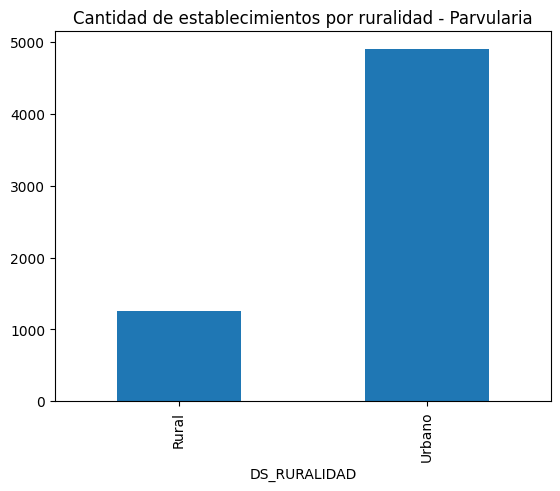

In [22]:
datos1= dfP.groupby("DS_RURALIDAD")["DS_NOM_ESTABLE"].count()


datos1.plot(kind="bar", title="Cantidad de establecimientos por ruralidad - Parvularia")

# <h1><center>1º Ciclo Básico </center></h1>

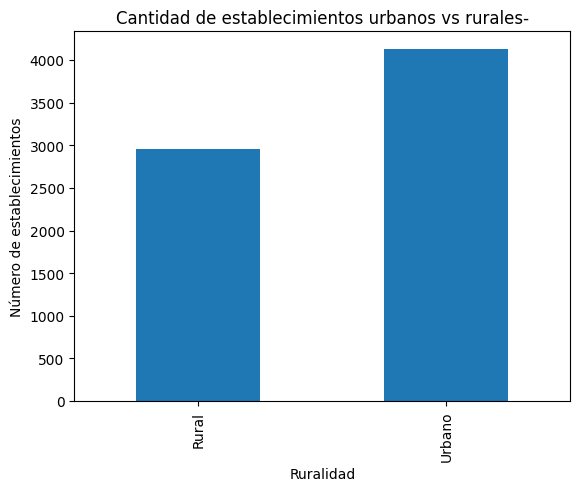

In [21]:
#Elijo el nivel de enseñanza
dfn= df1

#Numero total de filas
len(dfn)

"""#Valores Unicos de la columna DS_NOM_ESTABLE 
dfn["DS_NOM_ESTABLE"].nunique()

#checkeo cantidad de establecimientos duplicados
dfn["DS_NOM_ESTABLE"].duplicated().sum()"""
 

#verifico que se eliminaron
dfn["DS_NOM_ESTABLE"].duplicated().sum()

#Agrupo por ruralidad
datos2= dfn.groupby("DS_RURALIDAD")["DS_NOM_ESTABLE"].count()

#ploteo
datos2.plot(kind='bar', title='Cantidad de establecimientos urbanos vs rurales-')
plt.xlabel('Ruralidad')
plt.ylabel('Número de establecimientos')
plt.show()


# <h1><center>2º Ciclo Básico </center></h1>

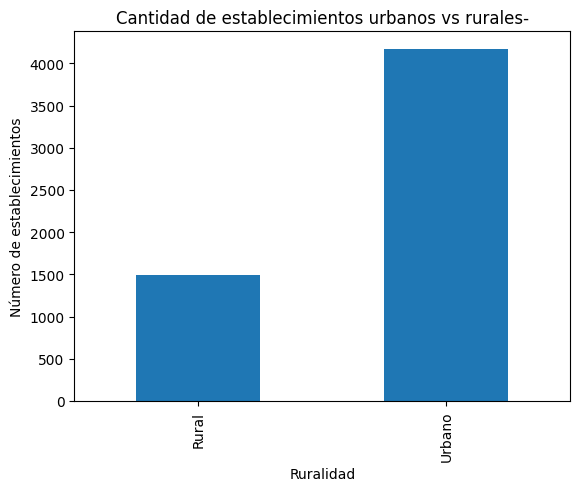

In [20]:
#Elijo el nivel de enseñanza
dfn= df2

#Numero total de filas
len(dfn)

#Valores Unicos de la columna DS_NOM_ESTABLE 
dfn["DS_NOM_ESTABLE"].nunique()

"""#Valores Unicos de la columna DS_NOM_ESTABLE 
dfn["DS_NOM_ESTABLE"].nunique()

#checkeo cantidad de establecimientos duplicados
dfn["DS_NOM_ESTABLE"].duplicated().sum()"""

#verifico que se eliminaron
dfn["DS_NOM_ESTABLE"].duplicated().sum()

#Agrupo por ruralidad
datos3= dfn.groupby("DS_RURALIDAD")["DS_NOM_ESTABLE"].count()

#ploteo
datos3.plot(kind='bar', title='Cantidad de establecimientos urbanos vs rurales-')
plt.xlabel('Ruralidad')
plt.ylabel('Número de establecimientos')
plt.show()

# <h1><center>Media </center></h1>

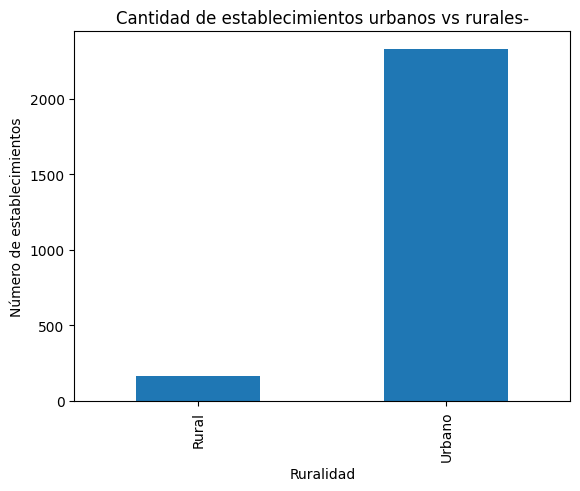

In [19]:
#Elijo el nivel de enseñanza
dfn= dfM

#Numero total de filas
len(dfn)

#Valores Unicos de la columna DS_NOM_ESTABLE 
dfn["DS_NOM_ESTABLE"].nunique()

#checkeo cantidad de establecimientos duplicados
dfn["DS_NOM_ESTABLE"].duplicated().sum()

#elimino establecimientos duplicados
dfn = dfn.drop_duplicates(subset="DS_NOM_ESTABLE")

#verifico que se eliminaron
dfn["DS_NOM_ESTABLE"].duplicated().sum()

#Agrupo por ruralidad
datos4= dfn.groupby("DS_RURALIDAD")["DS_NOM_ESTABLE"].count()

#ploteo
datos4.plot(kind='bar', title='Cantidad de establecimientos urbanos vs rurales-')
plt.xlabel('Ruralidad')
plt.ylabel('Número de establecimientos')
plt.show()

# <h1><center> GRAFICA ACUMULADA</center></h1>

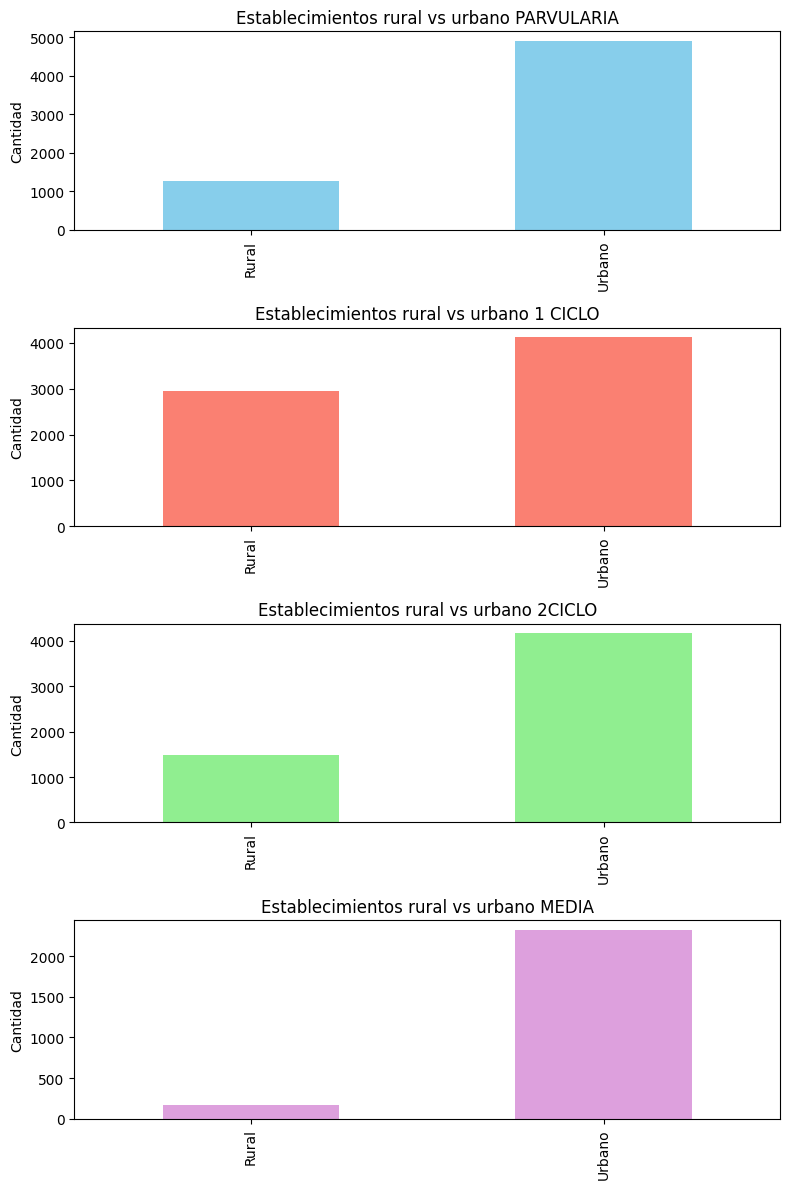

In [23]:
#Uso el subplot

fig, axes = plt.subplots(4, 1, figsize=(8, 12))  # (filas, columnas)

# 1️⃣ Primer gráfico
datos1.plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Establecimientos rural vs urbano PARVULARIA')
axes[0].set_xlabel('')
axes[0].set_ylabel('Cantidad')

# 2️⃣ Segundo gráfico (ejemplo con otra variable)
datos2.plot(kind='bar', ax=axes[1], color='salmon')
axes[1].set_title('Establecimientos rural vs urbano 1 CICLO')
axes[1].set_xlabel('')
axes[1].set_ylabel('Cantidad')

# 3️⃣ Tercer gráfico
datos3.plot(kind='bar', ax=axes[2], color='lightgreen')
axes[2].set_title('Establecimientos rural vs urbano 2CICLO')
axes[2].set_xlabel('')
axes[2].set_ylabel('Cantidad')

# 4️⃣ Cuarto gráfico
datos4.plot(kind='bar', ax=axes[3], color='plum')
axes[3].set_title('Establecimientos rural vs urbano MEDIA')
axes[3].set_xlabel('')
axes[3].set_ylabel('Cantidad')

plt.tight_layout()  # ajusta el espacio entre subplots
plt.show()

**ANALISIS DEL GRAFICO Y RESPUESTA :**

Podemos observar que el porcentaje de establecimientos rurales en la media son bajisimos
en cambio en el primer ciclo se parecen


---



# <h1><center> 4.b. ¿Cómo se distribuye el IVM según nivel de enseñanza y ruralidad?</center></h1>


# <h1><center>Parvularia </center></h1>

In [24]:
#elijo el df
dfn=dfP

dfn.groupby(["DS_RURALIDAD"])["IVM Establecimiento"].describe()

,count,mean,std,min,25%,50%,75%,max
DS_RURALIDAD,,,,,,,,
Rural,1260.0,61.068737,5.437212,42.227474,57.337776,60.818438,64.290233,89.975762
Urbano,4903.0,54.019154,5.097436,27.757575,50.913159,54.012330,57.043053,87.043774


# <h1><center>1º Ciclo Básico </center></h1>

In [ ]:
dfP.info()



In [ ]:
df1.info()


In [ ]:
df2.info()

In [ ]:

dfM.info()

In [ ]:
#elijo el df
dfn=df1

dfn.groupby(["DS_RURALIDAD"])["IVM Establecimiento"].describe()

In [ ]:
#elijo el df
dfn=df2

dfn.groupby(["DS_RURALIDAD"])["IVM Establecimiento"].describe()

In [ ]:
#elijo el df
dfn=dfM

dfn.groupby(["DS_RURALIDAD"])["IVM Establecimiento"].describe()

---


**1. Análisis de distribución entre niveles de enseñanza (por ejemplo, ver si Parvularia tiene IVM más alto que Media).**

¿¿ te interesa ajustar por el tamaño del establecimiento:??

In [ ]:

# Lista de tuplas (DataFrame, nombre del nivel)
niveles = [
    (dfP, "Parvularia"),
    (df1, "1° Ciclo Básico"),
    (df2, "2° Ciclo Básico"),
    (dfM, "Media")
]

# Calcular estadísticas descriptivas del IVM para cada nivel
resumenes = []
for df, nombre in niveles:
    desc = df["IVM Establecimiento"].describe().to_dict()
    desc["Nivel"] = nombre
    resumenes.append(desc)

# Convertir a DataFrame ordenado
df_resumen = pd.DataFrame(resumenes).set_index("Nivel")[["count","mean","std","min","25%","50%","75%","max"]]
df_resumen = df_resumen.round(2)

# Mostrar tabla final
display(df_resumen)




In [ ]:
plt.figure(figsize=(6,4))
plt.bar(df_resumen.index, df_resumen["mean"], color="skyblue")
plt.title("Promedio del IVM por Nivel de Enseñanza")
plt.xlabel("Nivel")
plt.ylabel("IVM promedio")
plt.xticks(rotation=15)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# df_resumen index = Nivel
# columnas: ['count','mean','std','min','25%','50%','75%','max']

# 1) Armar la estructura que usa matplotlib.bxp
bxp_stats = []
for nivel, row in df_resumen.iterrows():
    bxp_stats.append({
        'label' : nivel,
        'whislo': row['min'],   # mínimo
        'q1'    : row['25%'],   # percentil 25
        'med'   : row['50%'],   # mediana
        'q3'    : row['75%'],   # percentil 75
        'whishi': row['max'],   # máximo
        'fliers': []            # sin outliers (no los tenemos)
    })

# 2) Graficar
fig, ax = plt.subplots(figsize=(8,5))
ax.bxp(bxp_stats, showfliers=False)
ax.set_title('IVM por nivel (min–P25–P50–P75–max)')
ax.set_xlabel('Nivel')
ax.set_ylabel('IVM Establecimiento')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.xticks(rotation=15)
plt.show()

Los resultados muestran una clara disminución del IVM a medida que aumenta el nivel educativo.
La educación parvularia concentra los establecimientos con mayor vulnerabilidad, mientras que la educación media presenta los niveles más bajos.
Esto sugiere que las brechas socioeducativas son más pronunciadas en la primera infancia, y que las condiciones tienden a mejorar (o estabilizarse) en niveles superiores.

A medida que avanza el nivel educativo (desde Parvularia hasta Media), el IVM disminuye progresivamente. Esto sugiere que la vulnerabilidad social y educativa tiende a concentrarse en los niveles iniciales (educación parvularia), especialmente en la primera infancia.

---


**2. Análisis de distribución de IVM por ruralidad**

In [25]:
def add_level(df, nivel):
    cols = ['DS_RURALIDAD', 'IVM Establecimiento', 'N EVALUADO', 'ID_RBD']
    out = df[cols].copy()
    out['Nivel'] = nivel
    return out

dfall = pd.concat([
    add_level(dfP, 'Parvularia'),
    add_level(df1, '1° Ciclo Básico'),
    add_level(df2, '2° Ciclo Básico'),
    add_level(dfM, 'Media')
], ignore_index=True)

             Nivel DS_RURALIDAD  IVM Establecimiento
0  1° Ciclo Básico        Rural            43.400184
1  1° Ciclo Básico       Urbano            43.609622
2  2° Ciclo Básico        Rural            36.866174
3  2° Ciclo Básico       Urbano            38.993564
4            Media        Rural            19.672758
5            Media       Urbano            20.292701
6       Parvularia        Rural            61.068737
7       Parvularia       Urbano            54.019154


<Figure size 800x500 with 0 Axes>

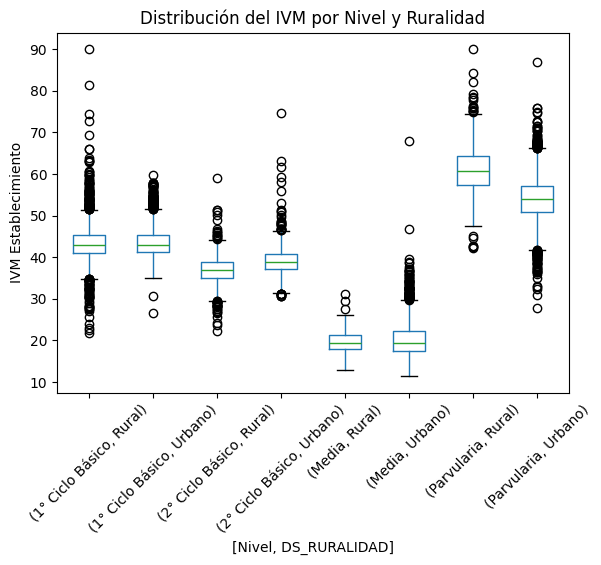

In [26]:
import matplotlib.pyplot as plt
 
# 1️⃣ Unir todos los niveles
dfP['Nivel'] = 'Parvularia'
df1['Nivel'] = '1° Ciclo Básico'
df2['Nivel'] = '2° Ciclo Básico'
dfM['Nivel'] = 'Media'

df_all = pd.concat([dfP, df1, df2, dfM], ignore_index=True)

# 2️⃣ Resumir: promedio de IVM por nivel y ruralidad
resumen = (
    df_all.groupby(['Nivel', 'DS_RURALIDAD'])['IVM Establecimiento']
    .mean()
    .reset_index()
    .sort_values(['Nivel', 'DS_RURALIDAD'])
)
print(resumen)

# 3️⃣ Graficar boxplot
plt.figure(figsize=(8,5))
df_all.boxplot(column='IVM Establecimiento', by=['Nivel', 'DS_RURALIDAD'], grid=False)
plt.title('Distribución del IVM por Nivel y Ruralidad')
plt.suptitle('')
plt.ylabel('IVM Establecimiento')
plt.xticks(rotation=45)
plt.show()

En general, los establecimientos Parvularios Rurales presentan el IVM más alto (61 puntos), superando a sus pares urbanos (54 puntos).
En los demás niveles (Básica y Media) las diferencias entre rural y urbano son pequeñas o invertidas, con valores levemente menores en el sector rural.
Esto sugiere que la vulnerabilidad es más pronunciada en la educación inicial rural, mientras que en los niveles superiores la brecha rural-urbana tiende a desaparecer o incluso revertirse

# <h1><center> 4.3 Pregunta Bono: Dimensiones de vulnerabilidad</center></h1>


# <h1><center>  5.1 Cálculo de IVM promedio por comuna (0.8 pts)</center></h1>


- 5.1.2.a calcule el promedio de la columna `IVM Establecimiento` según comuna para cada nivel
- 5.1.2.b calcule el promedio de la columna `IVM Establecimiento` según comuna para cada nivel
- 5.1.2.c calcule el promedio de la columna `IVM Establecimiento` según comuna para cada nivel
- 5.1.2.d calcule el promedio de la columna `IVM Establecimiento` según comuna para cada nivel



- 5.1.3.a Crear columna `IVM Promedio {NIVEL DE ENSEÑANZA}`
- 5.1.3.b Crear columna `IVM Promedio {NIVEL DE ENSEÑANZA}`
- 5.1.3.c Crear columna `IVM Promedio {NIVEL DE ENSEÑANZA}`
- 5.1.3.d Crear columna `IVM Promedio {NIVEL DE ENSEÑANZA}`

- 5.1.4 Crear dataframe unificado llamado `ivm_comunal` con columnas indicadas
* Comuna (nombre y ID)
* Región (ID)
* IVM Promedio Parvularia de la comuna
* IVM Promedio Básica Primer Ciclo de la comuna
* IVM Promedio Básica Segundo Ciclo de la comuna
* IVM Promedio Media de la comuna


In [27]:
promP = (dfP.groupby(['ID_REGION_ESTABLE', 'ID_COMUNA_ESTABLE', 'DS_COMUNA_ESTABLE'])
         ['IVM Establecimiento'].mean().reset_index()
         .rename(columns={'IVM Establecimiento': 'IVM Promedio Parvularia'}))

prom1 = (df1.groupby(['ID_REGION_ESTABLE', 'ID_COMUNA_ESTABLE', 'DS_COMUNA_ESTABLE'])
         ['IVM Establecimiento'].mean().reset_index()
         .rename(columns={'IVM Establecimiento': 'IVM Promedio Básica Primer Ciclo'}))

prom2 = (df2.groupby(['ID_REGION_ESTABLE', 'ID_COMUNA_ESTABLE', 'DS_COMUNA_ESTABLE'])
         ['IVM Establecimiento'].mean().reset_index()
         .rename(columns={'IVM Establecimiento': 'IVM Promedio Básica Segundo Ciclo'}))

promM = (dfM.groupby(['ID_REGION_ESTABLE', 'ID_COMUNA_ESTABLE', 'DS_COMUNA_ESTABLE'])
         ['IVM Establecimiento'].mean().reset_index()
         .rename(columns={'IVM Establecimiento': 'IVM Promedio Media'}))

# 2️⃣ Unir los 4 resultados en un solo DataFrame
ivm_comunal = (
    promP.merge(prom1, on=['ID_REGION_ESTABLE', 'ID_COMUNA_ESTABLE', 'DS_COMUNA_ESTABLE'], how='outer')
         .merge(prom2, on=['ID_REGION_ESTABLE', 'ID_COMUNA_ESTABLE', 'DS_COMUNA_ESTABLE'], how='outer')
         .merge(promM, on=['ID_REGION_ESTABLE', 'ID_COMUNA_ESTABLE', 'DS_COMUNA_ESTABLE'], how='outer')
)

# 3️⃣ Mostrar resultado
display(ivm_comunal.head())

,ID_REGION_ESTABLE,ID_COMUNA_ESTABLE,DS_COMUNA_ESTABLE,IVM Promedio Parvularia,IVM Promedio Básica Primer Ciclo,IVM Promedio Básica Segundo Ciclo,IVM Promedio Media
0,1,1101,Iquique,50.882970,45.131982,39.182182,22.109517
1,1,1107,Alto Hospicio,55.419776,46.599904,41.289463,24.250219
2,1,1401,Pozo Almonte,59.804991,44.159905,35.386361,22.676408
3,1,1402,Camiña,68.812360,46.127984,34.998365,17.966318
4,1,1403,Colchane,71.742419,56.888644,32.721880,27.648785


# <h1><center>  5.2 Establecimientos por comuna y ruralidad (0.8 pts) </center></h1>



- 5.2.1 Crear dataframe unificado llamado `estab_comunal`  con columnas indicadas`
- Contar la cantidad de establecimientos por comuna según ruralidad 


(Tenga en cuenta de que pueden aparecer establecimientos duplicados al combinar estos 4 DataFrames (por ejemplo, establecimientos que imparten múltiples niveles de enseñanza, desde 1º básico hasta 4º medio). Preocúpese de manejar estos casos antes de agrupar sus datos según ruralidad.)

In [ ]:
# 1️⃣ Combinar los 4 DataFrames (todos los niveles)
df_todos = pd.concat([dfP, df1, df2, dfM], ignore_index=True)

# 2️⃣ Eliminar duplicados de establecimientos (por su ID único)
# Esto evita contar varias veces el mismo colegio si aparece en más de un nivel
df_todos = df_todos.drop_duplicates(subset=['ID_RBD'])

# 3️⃣ Agrupar por comuna y ruralidad
conteo = (df_todos.groupby(['ID_COMUNA_ESTABLE', 'DS_RURALIDAD'])
                    ['ID_RBD'].nunique()
                    .reset_index()
                    .rename(columns={'ID_RBD': 'Cantidad_Establecimientos'}))

# 4️⃣ Pivotear para tener columnas separadas: Rural / Urbano
estab_comunal = (conteo.pivot(index='ID_COMUNA_ESTABLE', 
                              columns='DS_RURALIDAD', 
                              values='Cantidad_Establecimientos')
                          .fillna(0)
                          .reset_index())

# 5️⃣ Renombrar columnas para mayor claridad
estab_comunal = estab_comunal.rename(columns={
    'Rural': 'Estab_Rurales',
    'Urbano': 'Estab_Urbanos'
})

# 6️⃣ Calcular total y porcentaje rural
estab_comunal['Total_Estab'] = estab_comunal['Estab_Rurales'] + estab_comunal['Estab_Urbanos']
estab_comunal['Porcentaje_Rural'] = (estab_comunal['Estab_Rurales'] / estab_comunal['Total_Estab']) * 100

# 7️⃣ (Opcional) ordenar por % rural
estab_comunal = estab_comunal.sort_values('Porcentaje_Rural', ascending=False)

# Mostrar resultado
display(estab_comunal.head())


# <h1><center>   5.3 Unión de bases de datos y polígonos (0.4 pts) </center></h1>



- crear df agg comunal con dos previos dataframe y columnas indicadas
- crear base de datos unificada con secciones anteriores
- crear columna geometry de cada comuna

In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# 1) Normalizar claves de comuna (asegura tipos consistentes)
# ─────────────────────────────────────────────────────────────────────────────
for df in [ivm_comunal, estab_comunal]:
    df['ID_COMUNA_ESTABLE'] = (df['ID_COMUNA_ESTABLE']
                               .astype(str).str.strip())

# ─────────────────────────────────────────────────────────────────────────────
# 2) Unir métricas en un solo DataFrame 'agg_comunal' (sin geometría aún)
# ─────────────────────────────────────────────────────────────────────────────
cols_id = ['ID_REGION_ESTABLE', 'ID_COMUNA_ESTABLE', 'DS_COMUNA_ESTABLE']
keep_cols_ivm = cols_id + [
    'IVM Promedio Parvularia',
    'IVM Promedio Básica Primer Ciclo',
    'IVM Promedio Básica Segundo Ciclo',
    'IVM Promedio Media'
]
base_ivm = ivm_comunal[keep_cols_ivm].copy()

agg_comunal = (base_ivm
               .merge(estab_comunal, on='ID_COMUNA_ESTABLE', how='outer'))

# ─────────────────────────────────────────────────────────────────────────────
# 3) Detectar la columna de ID de comuna en el GeoDataFrame y normalizar
#    (ajusta a tu gdf real: prueba en este orden común de nombres en Chile)
# ─────────────────────────────────────────────────────────────────────────────
posibles_ids = ['ID_COMUNA', 'COD_COMUNA', 'CUT_COM', 'COMUNA', 'cod_comuna']
id_geo = next((c for c in posibles_ids if c in gdf_comunas.columns), None)
if id_geo is None:
    raise ValueError("No encuentro la columna de ID de comuna en gdf_comunas. "
                     f"Columnas disponibles: {list(gdf_comunas.columns)}")

gdf_tmp = gdf_comunas.copy()
gdf_tmp[id_geo] = gdf_tmp[id_geo].astype(str).str.strip()

# ─────────────────────────────────────────────────────────────────────────────
# 4) Unir geometría (merge a la derecha desde el lado geográfico para cubrir todo el mapa)
#    Si quieres mantener solo comunas con datos, usa how='inner'
# ─────────────────────────────────────────────────────────────────────────────
agg_comunal_geo = (gdf_tmp[[id_geo, 'geometry']]
                   .merge(agg_comunal, left_on=id_geo, right_on='ID_COMUNA_ESTABLE', how='left'))

# Convertir a GeoDataFrame final
agg_comunal = gpd.GeoDataFrame(agg_comunal_geo, geometry='geometry', crs=gdf_tmp.crs)

# ─────────────────────────────────────────────────────────────────────────────
# 5) Chequeos útiles
# ─────────────────────────────────────────────────────────────────────────────
# Comunas del shape sin match en tus tablas (si hay NaN en IVM o conteos)
faltantes = agg_comunal[agg_comunal['IVM Promedio Parvularia'].isna() &
                        agg_comunal['Total_Estab'].isna()][[id_geo, 'geometry']]
# display(faltantes.head())  # opcional

# Ordenar y ver
agg_comunal = agg_comunal.sort_values(['ID_REGION_ESTABLE', 'DS_COMUNA_ESTABLE'], na_position='last')
# display(agg_comunal.head())

# ─────────────────────────────────────────────────────────────────────────────
# 6) (Opcional) Exportar para SIG o informe
# ─────────────────────────────────────────────────────────────────────────────
# agg_comunal.to_file('agg_comunal.geojson', driver='GeoJSON')
# agg_comunal.to_file('agg_comunal.gpkg', driver='GPKG', layer='agg_comunal')


In [ ]:
agg_comunal.sample(20)

# <h1><center> 6.1 Mapa de calor (0.8 pts)  </center></h1>
Análisis de vulnerabilidad por comuna

- Genere mapas de calor de las comunas de Chile según el IVM promedio de los establecimientos educacionales(por nivel)
- Genere mapas de calor de las comunas de Chile según el IVM promedio de los establecimientos educacionales(por nivel)
- Genere mapas de calor de las comunas de Chile según el IVM promedio de los establecimientos educacionales(por nivel)
- Genere mapas de calor de las comunas de Chile según el IVM promedio de los establecimientos educacionales(por nivel)
- Analizar y comentar resultados
- responder a pregunta ¿Cómo se diferencia la vulnerabilidad en distintos sectores del país según nivel de enseñanza?

In [ ]:
gdf = agg_comunal.copy()

fig, ax = plt.subplots(figsize=(8,10))
gdf.plot(
    column="IVM Promedio Parvularia",
    ax=ax,
    legend=True,
    cmap="OrRd",
    edgecolor="white",
    linewidth=0.2,
    missing_kwds={"color":"lightgrey","edgecolor":"white","hatch":"///","label":"Sin datos"},
)
ax.set_title("IVM promedio por comuna — Parvularia")
ax.set_axis_off()
plt.tight_layout()
plt.savefig("mapa_ivm_parvularia.png", dpi=300)
plt.show()


In [ ]:
gdf = agg_comunal.copy()

fig, ax = plt.subplots(figsize=(8,10))
gdf.plot(
    column="IVM Promedio Básica Primer Ciclo",
    ax=ax,
    legend=True,
    cmap="OrRd",
    edgecolor="white",
    linewidth=0.2,
    missing_kwds={"color":"lightgrey","edgecolor":"white","hatch":"///","label":"Sin datos"},
)
ax.set_title("IVM promedio por comuna — Básica 1° Ciclo")
ax.set_axis_off()
plt.tight_layout()
plt.savefig("mapa_ivm_basica_1ciclo.png", dpi=300)
plt.show()

In [ ]:
gdf = agg_comunal.copy()

fig, ax = plt.subplots(figsize=(8,10))
gdf.plot(
    column="IVM Promedio Básica Segundo Ciclo",
    ax=ax,
    legend=True,
    cmap="OrRd",
    edgecolor="white",
    linewidth=0.2,
    missing_kwds={"color":"lightgrey","edgecolor":"white","hatch":"///","label":"Sin datos"},
)
ax.set_title("IVM promedio por comuna — Básica 2° Ciclo")
ax.set_axis_off()
plt.tight_layout()
plt.savefig("mapa_ivm_basica_2ciclo.png", dpi=300)
plt.show()

In [ ]:

gdf = agg_comunal.copy()

fig, ax = plt.subplots(figsize=(8,10))
gdf.plot(
    column="IVM Promedio Media",
    ax=ax,
    legend=True,
    cmap="OrRd",
    edgecolor="white",
    linewidth=0.2,
    missing_kwds={"color":"lightgrey","edgecolor":"white","hatch":"///","label":"Sin datos"},
)
ax.set_title("IVM promedio por comuna — Media")
ax.set_axis_off()
plt.tight_layout()
plt.savefig("mapa_ivm_media.png", dpi=300)
plt.show()

# <h1><center>  6.2 Relación entre ruralidad comunal y vulnerabilidad (0.7 pts)  </center></h1>
 

En la sección **5.2** definimos el **porcentaje de ruralidad** de cada comuna según la cantidad de establecimientos rurales en cada una. Analice y visualice los datos en `agg_comunal` para responder la siguiente pregunta:

* ¿Hay alguna correlación entre el IVM promedio y el porcentaje de ruralidad en las comunas de Chile?